# Day01 — Financial sentiment: загрузка и EDA

Цель — понять данные до обучения модели. **Supervised classification** связывает текст `text` с заданной человеком меткой `sentiment`. Один объект здесь — финансовое предложение, не статья, компания или торговая сделка.

Три класса: `negative`, `neutral`, `positive`. Числовое кодирование и preprocessing будут в day02, обучение — в day03. Этот notebook вызывает функции из `src/`, а не содержит вторую независимую реализацию.

Запускайте **Restart Kernel → Run All**. Нужен interpreter проекта `venv/`. Данные готовятся отдельно:

```bash
PYTHONPATH=src venv/bin/python -m finnews_sentiment.data.prepare_phrasebank --download
```

Повторные запуски notebook работают offline. Источник: [Financial PhraseBank](https://huggingface.co/datasets/takala/financial_phrasebank), Malo et al. (2014), лицензия CC-BY-NC-SA-3.0. Не объединяем перекрывающиеся agreement subsets.

## D1-00 — окружение и учебный workflow

`AGENTS.md` задаёт правила работы агента, `SPEC.md` — поведение программы, `PLAN.md` — порядок маленьких проверяемых изменений. Это помогает оценивать код Codex по контракту и наблюдаемому результату.

Сначала явно находим корень проекта и подключаем `src/`. Устанавливать весь стек Transformers для EDA не требуется. Запишем версии фактически использованных библиотек; pinning помогает повторить эксперимент, но само по себе не заменяет clean-kernel проверку.

In [7]:
import importlib.metadata
import json
import os
import platform
import sys
from pathlib import Path

def find_project_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / "SPEC.md").is_file() and (candidate / "src/finnews_sentiment").is_dir():
            return candidate
    raise RuntimeError("Открой notebook из корня проекта или notebooks/")

ROOT: Path = find_project_root(Path.cwd())
sys.path.insert(0, str(ROOT / "src"))
REPORTS = ROOT / "reports/day01"
REPORTS.mkdir(parents=True, exist_ok=True)
os.environ.setdefault("MPLCONFIGDIR", str(ROOT / ".cache/matplotlib"))

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Markdown, display
from finnews_sentiment.data.load_data import CLASS_ORDER, load_raw_news
from finnews_sentiment.data.prepare_phrasebank import prepare_phrasebank
from finnews_sentiment.visualization.eda import (
    class_distribution, class_examples, quality_summary, text_lengths,
    plot_class_distribution, plot_text_length_distribution,
)

package_names = ["pandas", "numpy", "matplotlib", "seaborn", "nbformat", "nbclient", "ipykernel"]
environment = {"python": platform.python_version(), "packages": {name: importlib.metadata.version(name) for name in package_names}}
(REPORTS / "environment.json").write_text(json.dumps(environment, indent=2) + "\n", encoding="utf-8")
print("Interpreter:", sys.executable)
print("Root:", ROOT)
display(environment)

Interpreter: /home/makarlistkov/projects/Text-classification/venv/bin/python
Root: /home/makarlistkov/projects/Text-classification


{'python': '3.14.6',
 'packages': {'pandas': '3.0.6',
  'numpy': '2.5.3',
  'matplotlib': '3.11.2',
  'seaborn': '0.13.2',
  'nbformat': '5.11.1',
  'nbclient': '0.11.0',
  'ipykernel': '7.4.0'}}

**Checkpoint:** корень найден, reusable modules импортированы, environment manifest сохранён.

**Самопроверка:** почему нельзя считать ячейку воспроизводимой только потому, что она сработала один раз в уже запущенном kernel?

## D1-01 — источник и загрузка

Financial PhraseBank содержит предложения, размеченные по финансовой тональности. Выбрали `sentences_75agree`: минимум 75% разметчиков согласны с меткой. Это порог согласия, **не train/test split** и не вероятность ответа модели.

Адаптер читает один member ZIP в ISO-8859-1 и разделяет строку по последнему `@`. Содержание предложения и порядок строк остаются прежними. SHA-256 проверяет точные байты архива; pinned revision фиксирует источник. Conversion в CSV не является очисткой NLP.

In [2]:
source = json.loads((ROOT / "configs/dataset.json").read_text(encoding="utf-8"))
# Только локальный проверенный archive; network в этом notebook не используется.
CSV_PATH = prepare_phrasebank(ROOT)
df = load_raw_news(CSV_PATH)
assert df.shape == (source["expected_rows"], 2)
assert list(CLASS_ORDER) == source["class_order"]
raw_checkpoint = df.copy(deep=True)
print("Source revision:", source["revision"])
print("Archive SHA-256:", source["archive_sha256"])
print("Shape (rows, columns):", df.shape)
display(df.head())

Source revision: 8d3fe0c36d5feec6b3cc5e455b0fcb4820fb9964
Archive SHA-256: 0e1a06c4900fdae46091d031068601e3773ba067c7cecb5b0da1dcba5ce989a6
Shape (rows, columns): (3453, 2)


,text,sentiment
0,"According to Gran , the company has no plans t...",neutral
1,With the new production plant the company woul...,positive
2,"For the last quarter of 2010 , Componenta 's n...",positive
3,"In the third quarter of 2010 , net sales incre...",positive
4,Operating profit rose to EUR 13.1 mn from EUR ...,positive


**Checkpoint:** реальные данные загружены в canonical DataFrame `(N, 2)`, без удаления строк и fit.

**Самопроверка:** почему увеличение agreement threshold может уменьшать число примеров и одновременно менять сложность задачи?

## D1-02 — структура и качество

`dtypes` показывают представление значений в pandas, а не их смысл. Missing text, строка из пробелов и повторяющееся предложение — разные проблемы. Дубликаты могут сделать test слишком лёгким, если одинаковые тексты попадут в train и test. Один текст с несколькими классами требует отдельной политики.

Сейчас мы **измеряем** проблемы, не удаляем строки. В отчёте duplicate count означает число повторений сверх первого, conflicting texts — число уникальных непустых текстов с несколькими непустыми метками. Сравнение текстов точное, без нормализации; near-duplicates ещё не исследованы.

In [3]:
df.info()
display(df.dtypes.rename("dtype").to_frame())
display(df.isna().sum().rename("missing").to_frame())
quality = quality_summary(df)
(REPORTS / "quality.json").write_text(json.dumps(quality, indent=2) + "\n", encoding="utf-8")
display(quality)
pd.testing.assert_frame_equal(df, raw_checkpoint)

<class 'pandas.DataFrame'>
RangeIndex: 3453 entries, 0 to 3452
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   text       3453 non-null   str  
 1   sentiment  3453 non-null   str  
dtypes: str(2)
memory usage: 54.1 KB


,dtype
text,str
sentiment,str


,missing
text,0
sentiment,0


{'rows': 3453,
 'columns': ['text', 'sentiment'],
 'dtypes': {'text': 'str', 'sentiment': 'str'},
 'missing': {'text': 0, 'sentiment': 0},
 'blank_texts': 0,
 'duplicate_rows': 5,
 'duplicate_texts': 5,
 'conflicting_texts': 0}

**Checkpoint:** качество измерено; исходная таблица не изменена.

**Самопроверка:** если missing=0, почему это ещё не доказывает корректность разметки и отсутствие leakage?

## D1-03 — распределение классов

Counts описывают число объектов каждого класса, fraction = count / N. При missing labels сумма долей меньше 1; пропуски учитываются отдельно, не становятся четвёртым классом.

Если `neutral` преобладает, модель, всегда предсказывающая neutral, может иметь высокую **accuracy**, но полностью пропускать другие классы. Позже используем **macro F1** — среднее F1 трёх классов с одинаковым весом, вместе с per-class precision/recall/support.

,count,fraction
sentiment,,
negative,420,0.121633
neutral,2146,0.621489
positive,887,0.256878


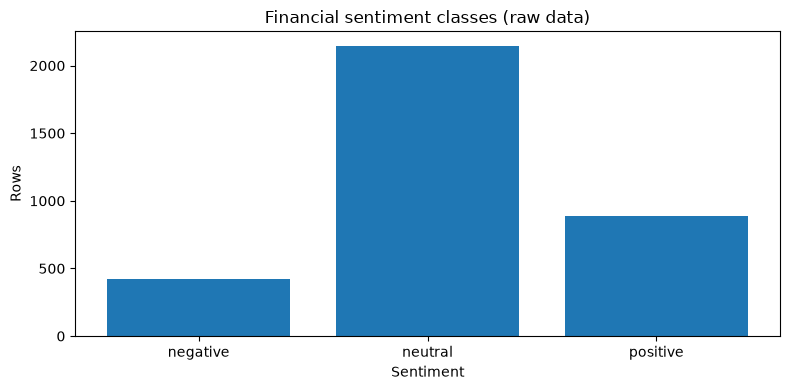

Доля крупнейшего класса: 62.1%; это описательная доля, не измеренная test accuracy.


In [4]:
distribution = class_distribution(df)
assert int(distribution["count"].sum()) + int(df["sentiment"].isna().sum()) == len(df)
distribution.to_csv(REPORTS / "class_distribution.csv")
display(distribution)
fig = plot_class_distribution(df, REPORTS / "sentiment_distribution.png")
display(fig)
plt.close(fig)
majority_share = float(distribution["fraction"].max())
print(f"Доля крупнейшего класса: {majority_share:.1%}; это описательная доля, не измеренная test accuracy.")

**Checkpoint:** таблица и график классов сохранены, denominator проверен.

**Самопроверка:** почему нельзя выбрать accuracy единственной метрикой только потому, что её проще объяснить?

## D1-04 — длины и примеры

Длина в символах измеряет размер строки; whitespace word count считает элементы `split()`. Это **не token count** модели: subword tokenizer может разбить одно слово на несколько tokens. Посмотрим median, quantiles и max — среднее может скрывать длинный хвост.

Примеры выводятся в исходном порядке. Они помогают понять задачу, но несколько примеров не доказывают качество разметки всего датасета. Мы сохраняем исходные числа, отрицания и пунктуацию.

,char_count,word_count
count,3453.0,3453.0
mean,124.863597,22.756733
std,56.442017,10.067928
min,9.0,2.0
25%,81.0,15.0
50%,116.0,21.0
75%,160.0,29.0
95%,231.0,42.4
max,315.0,81.0


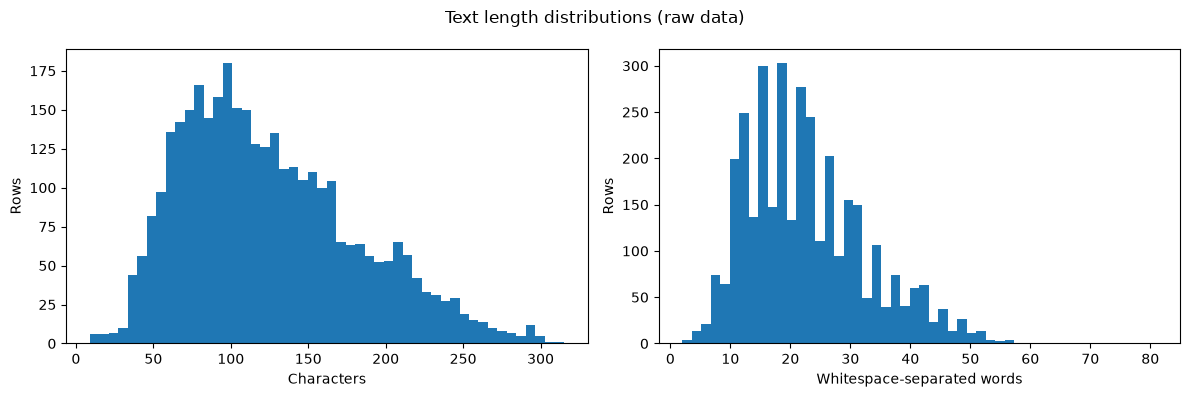


=== negative ===
• Jan. 6 -- Ford is struggling in the face of slowing truck and SUV sales and a surfeit of up-to-date , gotta-have cars .
• Pharmaceuticals group Orion Corp reported a fall in its third-quarter earnings that were hit by larger expenditures on R&D and marketing .
• However , the growth margin slowed down due to the financial crisis .

=== neutral ===
• According to Gran , the company has no plans to move all production to Russia , although that is where the company is growing .
• At the request of Finnish media company Alma Media 's newspapers , research manager Jari Kaivo-oja at the Finland Futures Research Centre at the Turku School of Economics has drawn up a future scenario for Finland 's national economy by using a model developed by the University of Denver .
• In Sweden , Gallerix accumulated SEK denominated sales were down 1 % and EUR denominated sales were up 11 % .

=== positive ===
• With the new production plant the company would increase its capacity to me

In [5]:
lengths = text_lengths(df)
lengths.to_csv(REPORTS / "text_lengths.csv", index_label="source_row")
display(lengths.describe(percentiles=[0.25, 0.5, 0.75, 0.95]))
fig = plot_text_length_distribution(df, REPORTS / "text_length_distribution.png")
display(fig)
plt.close(fig)
examples = class_examples(df, n=3)
for sentiment, texts in examples.items():
    print(f"\n=== {sentiment} ===")
    for text in texts:
        print("•", text)
pd.testing.assert_frame_equal(df, raw_checkpoint)

**Checkpoint:** исходные длины, два histogram и примеры каждого класса доступны.

**Самопроверка:** почему до удаления цифр или слова `not` стоит сформулировать гипотезу о возможной потере сигнала?

## D1-05 — наблюдения и границы выводов

Запишем выводы из фактических данных, отделяя измерение от гипотезы. Day01 ещё не даёт метрик классификатора. EDA всей таблицы проверяет структуру; подбор model/preprocessing дальше выполняется на train/validation. После заморозки настроек held-out test даст итоговую оценку.

Этот датасет описывает финансовую тональность исторических предложений. Работа на современных источниках и влияние на рыночную доходность требуют других данных и отдельной проверки.

In [6]:
word_median = float(lengths["word_count"].median())
word_max = int(lengths["word_count"].max())
char_median = float(lengths["char_count"].median())
class_lines = "\n".join(f"- {label}: {int(row['count'])} ({row['fraction']:.1%})." for label, row in distribution.iterrows())
observations = f"""# Day01 — наблюдения

Источник: takala/financial_phrasebank, sentences_75agree, revision {source['revision']}.
Лицензия: CC-BY-NC-SA-3.0. Malo et al. (2014).

## Измерения

- Размер: {len(df)} строк, {len(df.columns)} колонки.
- Пропуски: {quality['missing']}; строки с пустым текстом без missing: {quality['blank_texts']}.
- Повторы строк сверх первого: {quality['duplicate_rows']}.
- Повторы непустых текстов сверх первого: {quality['duplicate_texts']}.
- Уникальные тексты с противоречащими метками: {quality['conflicting_texts']}.
{class_lines}
- Доля крупнейшего класса: {majority_share:.1%}.
- Median длины: {char_median:g} символов, {word_median:g} слов по пробелам; max {word_max} слов.

## Интерпретация и следующие вопросы

- Классы несбалансированы: accuracy нужно дополнять macro F1 и per-class metrics.
- Точные дубликаты требуют явной политики до split; near-duplicates здесь не проверены.
- 75% agreement не означает безошибочную разметку. Несогласие и неоднозначность остаются.
- Сохраняем raw data; day02 определит минимальную очистку и судьбу duplicates/conflicts.
- Проверим, теряются ли отрицания, суммы, проценты и названия компаний при preprocessing.
- Word count не равен subword token count. Для TF-IDF важны vocabulary и n-grams, а не Transformer truncation.
- EDA не доказывает качество модели, применимость к live news или прогноз доходности.
- После day01 нет обученной модели и нет подтверждённых classification metrics.
"""
(REPORTS / "observations.md").write_text(observations, encoding="utf-8")
display(Markdown(observations))
pd.testing.assert_frame_equal(df, raw_checkpoint)
print("Day01 завершён: raw rows preserved; reports:", sorted(p.name for p in REPORTS.iterdir()))

# Day01 — наблюдения

Источник: takala/financial_phrasebank, sentences_75agree, revision 8d3fe0c36d5feec6b3cc5e455b0fcb4820fb9964.
Лицензия: CC-BY-NC-SA-3.0. Malo et al. (2014).

## Измерения

- Размер: 3453 строк, 2 колонки.
- Пропуски: {'text': 0, 'sentiment': 0}; строки с пустым текстом без missing: 0.
- Повторы строк сверх первого: 5.
- Повторы непустых текстов сверх первого: 5.
- Уникальные тексты с противоречащими метками: 0.
- negative: 420 (12.2%).
- neutral: 2146 (62.1%).
- positive: 887 (25.7%).
- Доля крупнейшего класса: 62.1%.
- Median длины: 116 символов, 21 слов по пробелам; max 81 слов.

## Интерпретация и следующие вопросы

- Классы несбалансированы: accuracy нужно дополнять macro F1 и per-class metrics.
- Точные дубликаты требуют явной политики до split; near-duplicates здесь не проверены.
- 75% agreement не означает безошибочную разметку. Несогласие и неоднозначность остаются.
- Сохраняем raw data; day02 определит минимальную очистку и судьбу duplicates/conflicts.
- Проверим, теряются ли отрицания, суммы, проценты и названия компаний при preprocessing.
- Word count не равен subword token count. Для TF-IDF важны vocabulary и n-grams, а не Transformer truncation.
- EDA не доказывает качество модели, применимость к live news или прогноз доходности.
- После day01 нет обученной модели и нет подтверждённых classification metrics.


Day01 завершён: raw rows preserved; reports: ['class_distribution.csv', 'environment.json', 'observations.md', 'quality.json', 'sentiment_distribution.png', 'text_length_distribution.png', 'text_lengths.csv']


**Самопроверка после day01:**

1. Что является одним объектом и target? Почему это multiclass task?
2. Что фиксируют source revision, SHA-256 и environment manifest?
3. В чём отличие missing text, blank text, duplicate и conflicting labels?
4. Почему macro F1 помогает при дисбалансе и почему пока мы его не вычисляем?
5. Какие решения относятся к day02, а какие должны ждать train/validation split?

Следующий шаг: **D2-01 — минимальная cleanup policy**, с гипотезами о сохранении финансового сигнала.